In [1]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import plot_decomposition
from qiskit import QuantumCircuit


def fsim(theta, phi):
    qc = QuantumCircuit(2, name="fsim")
    qc.append(XXPlusYYGate(2 * theta), [0, 1])
    qc.cp(phi, 0, 1)
    return qc.to_gate()


### Usage as a Decomposer

In [2]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 3), 1 / 3, "sqrt3cx"),
    (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 6), 1 / 6, "sqrt6fsim"),
    # (SwapGate(), 0.0, "swap"),
    # (SwapGate().power(1 / 2), 1 / 2, "eswap"),
    # (SwapGate().power(1 / 3), 1 / 3, "eswap"),
]
gate_set, costs, names = zip(*isa)
isa = DiscreteISA(gate_set, costs, names, precompute_polytopes=False, max_depth=16)
decomposer = GulpsDecomposer(isa=isa)

if hasattr(decomposer.isa, "coverage_set"):
    report = coverage_report(decomposer.isa.coverage_set)

In [3]:
# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=0))

[array([0.08333333, 0.        , 0.        ]), array([1.66666667e-01, 1.38777878e-17, 0.00000000e+00]), array([0.25, 0.  , 0.  ]), array([3.33333333e-01, 2.77555756e-17, 0.00000000e+00]), array([0.39082226, 0.02584441, 0.        ]), array([0.39082226, 0.10917774, 0.        ]), array([0.39082226, 0.19251107, 0.        ]), array([0.39082226, 0.25847022, 0.01737419]), array([0.39082226, 0.25847022, 0.10070752]), array([0.36783129, 0.25847022, 0.16104988])]


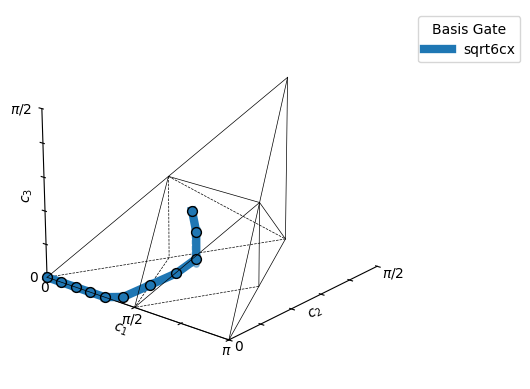

In [4]:
try:
    i += 1
except NameError:
    i = 0
r = decomposer._best_decomposition(
    GateInvariants.from_unitary(random_unitary(4, seed=i))
)
print([ri.weyl for ri in r.intermediates])
fig = plot_decomposition(r.intermediates, r.sentence, isa)

In [6]:
logger.setLevel("INFO")
N = 1_000

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        v = Operator(decomposer(u))
        fid = average_gate_fidelity(u, v)

        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

# === Fidelity Statistics ===
fidelities = np.array(fidelities)
print(f"\n{'=' * 50}")
print(f"  BENCHMARK RESULTS ({N} random unitaries)")
print(f"{'=' * 50}")

print(f"\n📊 Fidelity Statistics:")
print(f"  ✔ Completed: {len(fidelities)} / {N}")
print(f"  ✘ Failures:  {failures}")
print(f"  → Median:    {np.median(fidelities):.10f}")
print(f"  → Mean:      {np.mean(fidelities):.10f}")
print(f"  → Min:       {np.min(fidelities):.10f}")

# === Timing Statistics ===
if all_timings:
    phase_names = list(all_timings[0].keys())
    timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])

    print(f"\n⏱  Phase Timing (average per decomposition):")
    for k, mean_time in zip(phase_names, timing_array.mean(axis=0)):
        print(f"  {k:>20}: {mean_time * 1000:8.2f} ms")
    print(f"  {'-' * 32}")
    print(f"  {'Total':>20}: {timing_array.sum(axis=1).mean() * 1000:8.2f} ms")

# === Cache Statistics ===
cache_stats = decomposer._local_synthesis._cache.stats
print(f"\n💾 Segment Solver Cache:")
print(f"  → Hits:      {cache_stats['hits']:,}")
print(f"  → Misses:    {cache_stats['misses']:,}")
print(f"  → Hit Rate:  {cache_stats['hit_rate'] * 100:.1f}%")
print(f"  → Entries:   {cache_stats['entries']}")
print(f"  → Steps:     {cache_stats['steps']}")

print(f"\n{'=' * 50}\n")

Decomposing random unitaries: 100%|██████████| 1000/1000 [01:21<00:00, 12.25it/s]


  BENCHMARK RESULTS (1000 random unitaries)

📊 Fidelity Statistics:
  ✔ Completed: 1000 / 1000
  ✘ Failures:  0
  → Median:    1.0000000000
  → Mean:      1.0000000000
  → Min:       1.0000000000

⏱  Phase Timing (average per decomposition):
           lp_sentence:    14.49 ms
              segments:    62.97 ms
  --------------------------------
                 Total:    77.45 ms

💾 Segment Solver Cache:
  → Hits:      3,809
  → Misses:    4,745
  → Hit Rate:  44.5%
  → Entries:   38
  → Steps:     14




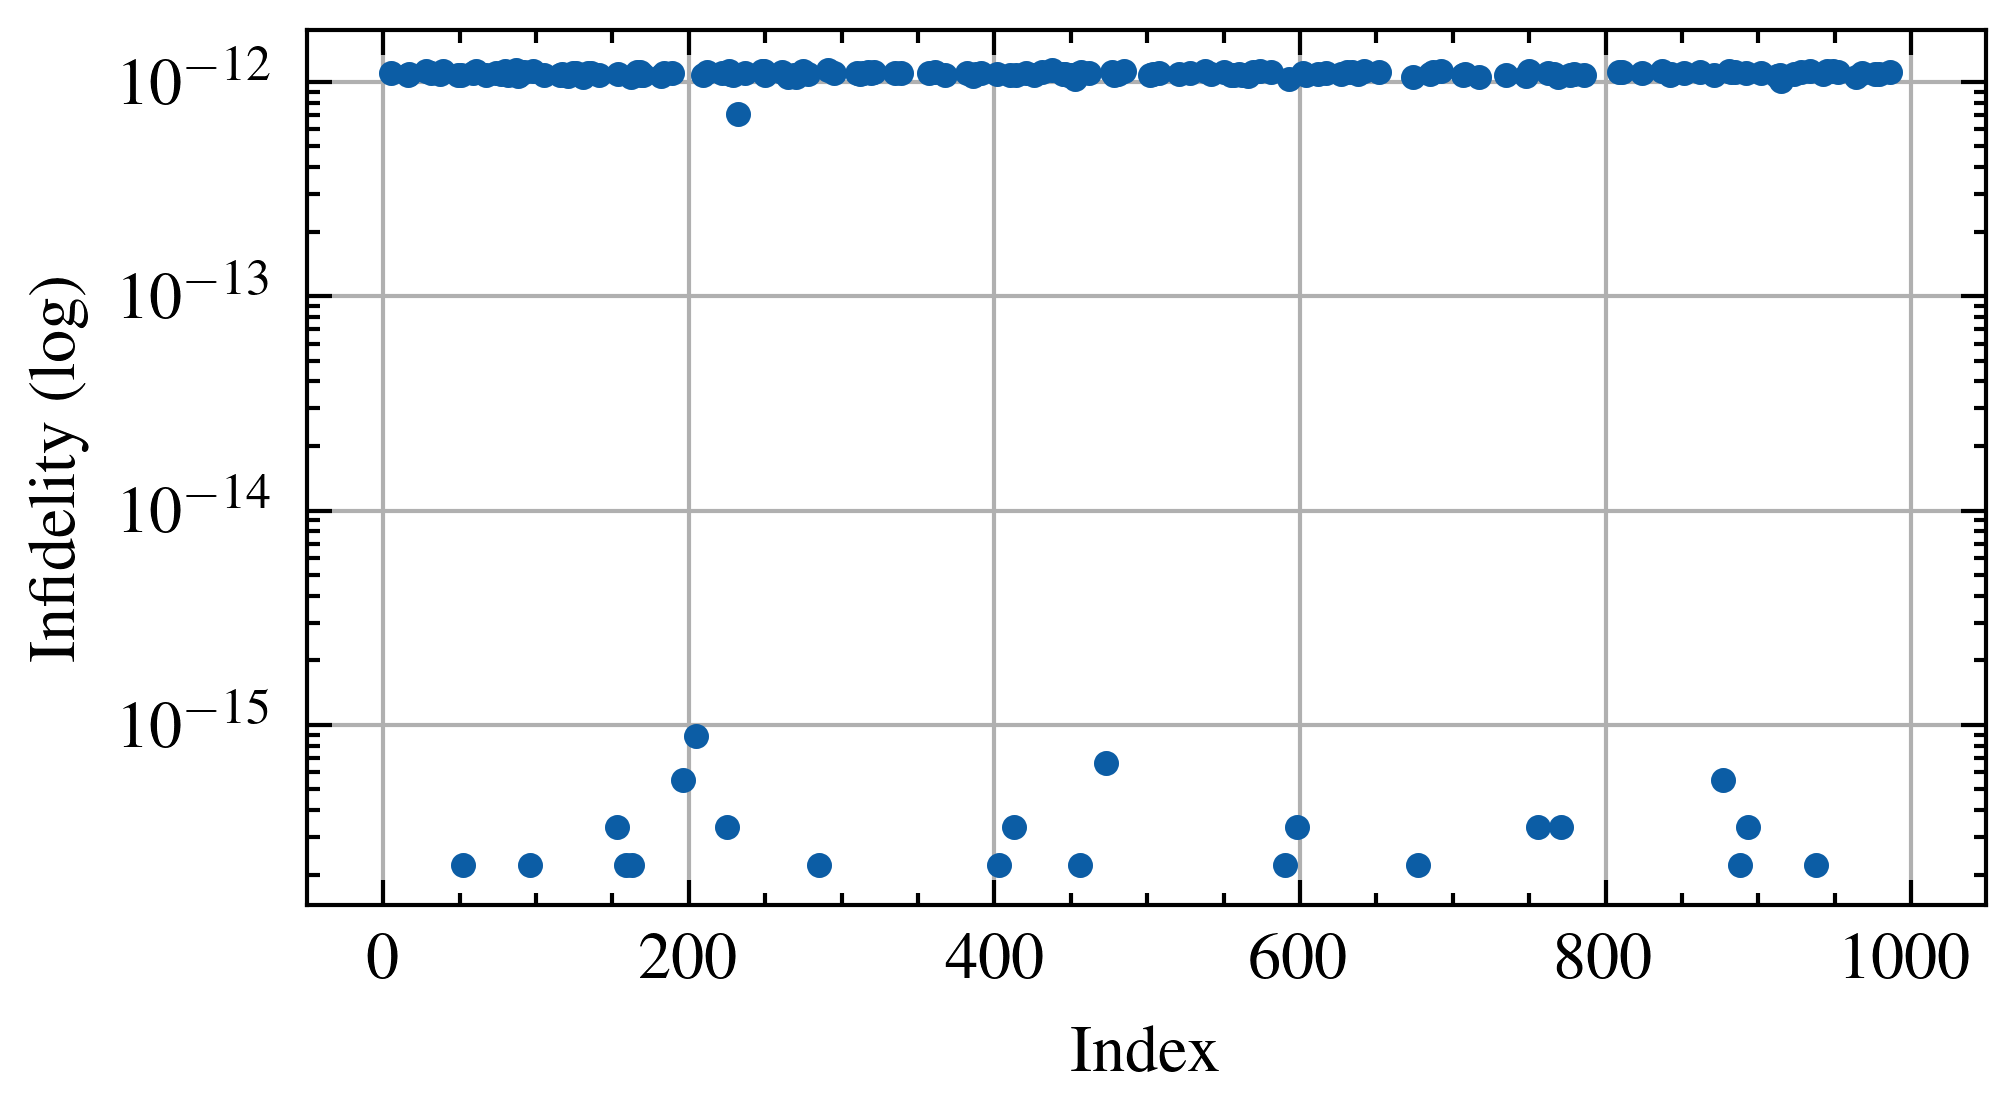

In [7]:
# make a plot for the fidelities
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax.plot(1 - fidelities, marker="o", markersize=2, linestyle="None")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity (log)")
    ax.set_yscale("log")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

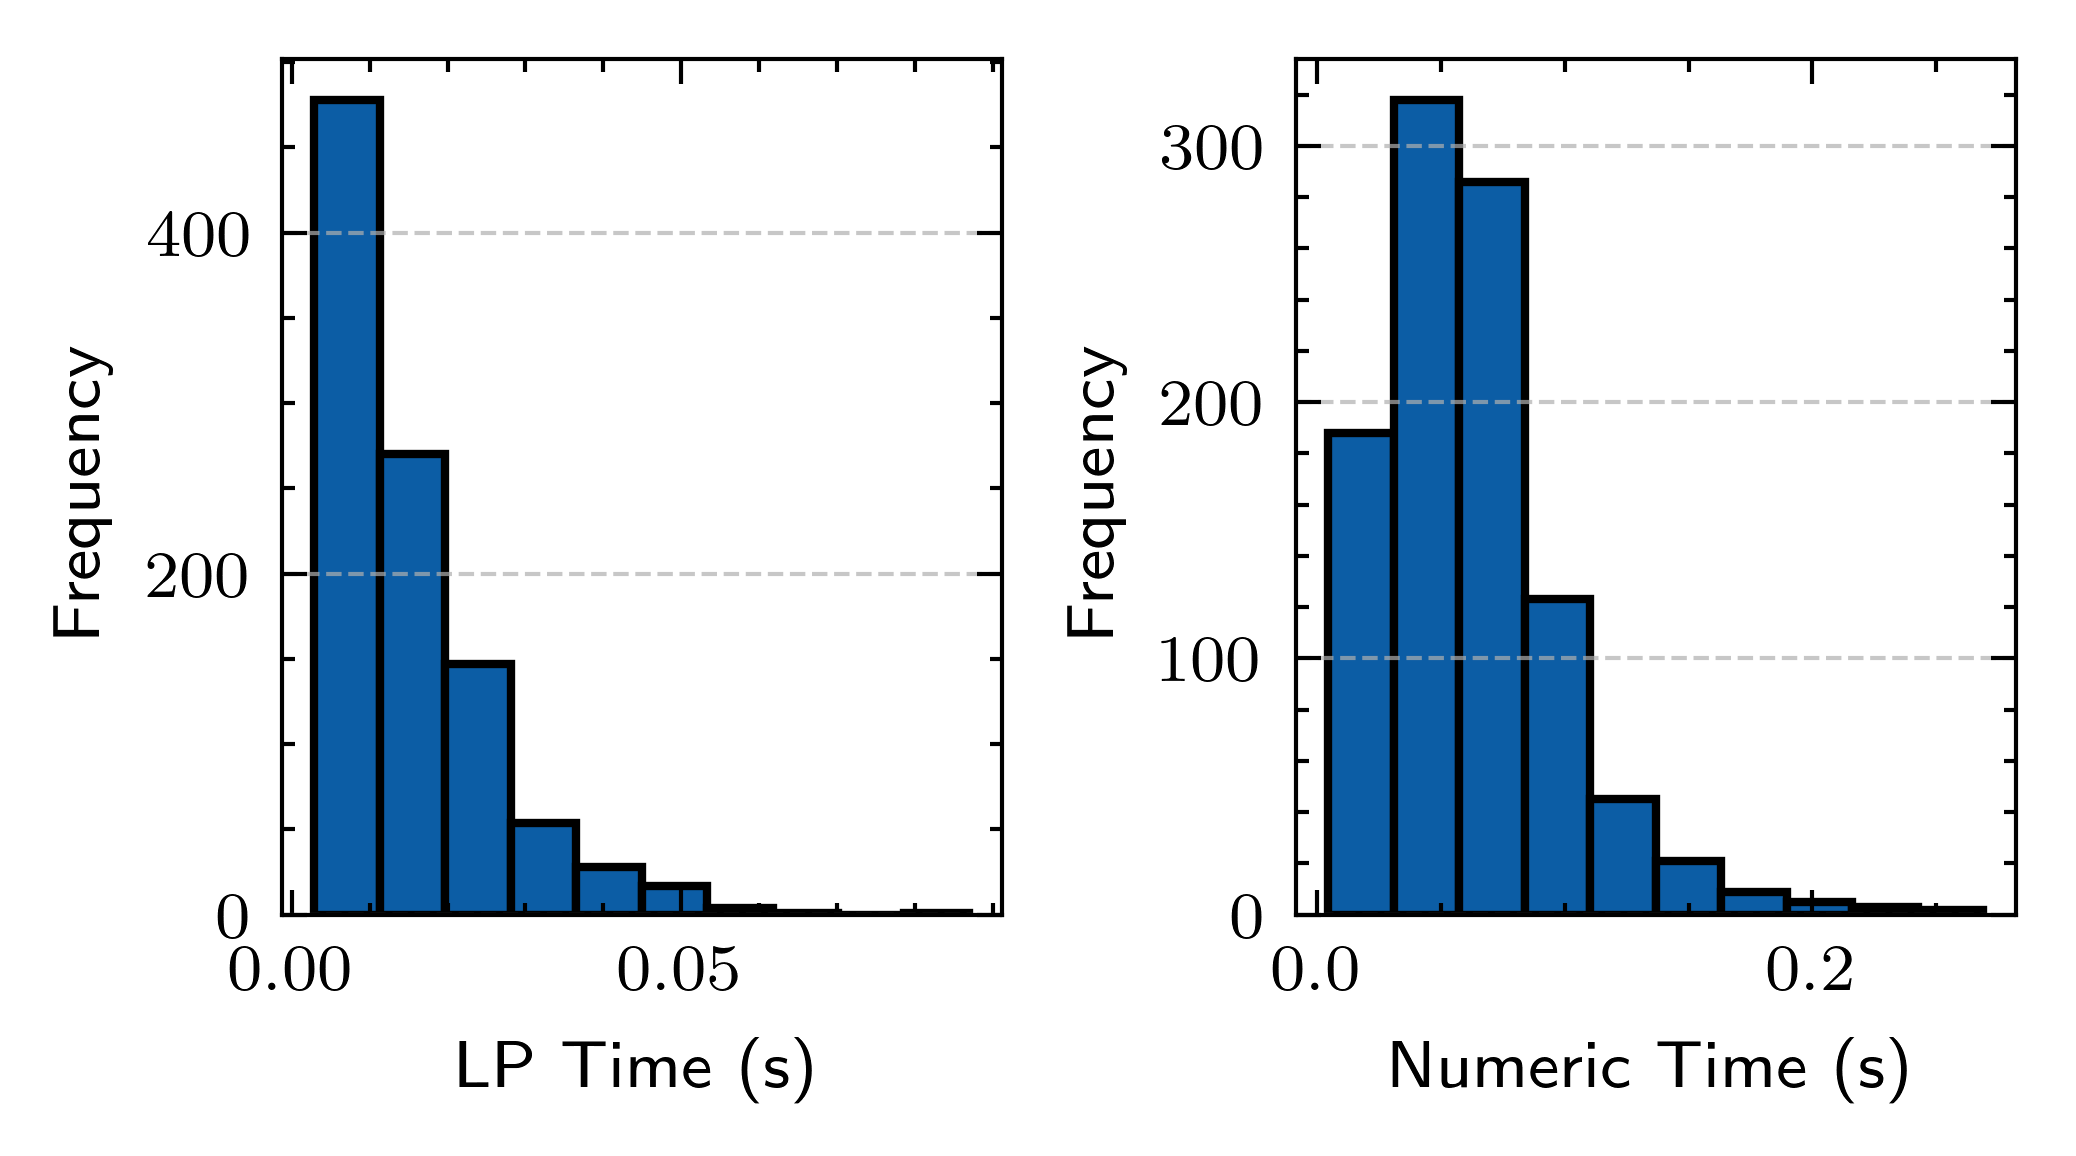

In [8]:
# Convert list of dicts to lists of values
lp_times = [d["lp_sentence"] for d in all_timings]
numeric_times = [d["segments"] for d in all_timings]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2))

    axes[0].set_xlabel("LP Time (s)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[0].hist(lp_times, edgecolor="black")

    axes[1].set_xlabel("Numeric Time (s)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(numeric_times, edgecolor="black")

    fig.tight_layout()
plt.show()